# 지역 건강 불평등 가설 검정

**분석 목적:** 한국 지역사회건강조사(CHS, 2015-2025) 데이터를 활용하여 지역 간 건강 불평등의 주요 가설을 통계적으로 검정합니다.

| 가설 | 내용 | 유의수준 |
|------|------|---------|
| H1 | 도·군(농촌) 지역은 광역시(도시)보다 건강나쁨·미충족의료 비율이 유의하게 높다 | α=0.05 |
| H2 | 미충족의료율이 높은 지역일수록 우울증상율과 건강악화율이 높다 | α=0.05 |
| H3 | COVID-19 이후 지역 간 건강 격차(표준편차)가 소폭 감소했다 | α=0.05 |
| H4 | 사회적 신뢰(이웃 신뢰)가 높은 지역일수록 정신건강 지표가 개선된다 | α=0.05 |

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
def set_korean_font():
    font_candidates = ['AppleGothic', 'NanumGothic', 'Malgun Gothic', 'DejaVu Sans']
    available = [f.name for f in fm.fontManager.ttflist]
    for font in font_candidates:
        if font in available:
            matplotlib.rc('font', family=font)
            print(f'한글 폰트 설정: {font}')
            return
    print('경고: 한글 폰트를 찾지 못했습니다. 기본 폰트 사용')

set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 경로 및 매핑 정의
BASE = '/Users/sim-yujin/[3-2] SocialIntelligence/팀프로젝트/socialInteligence/health/data/'

CITY_TO_CODE = {
    'A': 11, 'B': 26, 'C': 27, 'D': 28, 'E': 29, 'F': 30, 'G': 31,
    'H': 36, 'I': 41, 'J': 42, 'K': 43, 'L': 44, 'M': 45, 'N': 46,
    'O': 47, 'P': 48, 'Q': 50
}

REGION_NAMES = {
    11: '서울', 26: '부산', 27: '대구', 28: '인천', 29: '광주',
    30: '대전', 31: '울산', 36: '세종', 41: '경기', 42: '강원',
    43: '충북', 44: '충남', 45: '전북', 46: '전남', 47: '경북',
    48: '경남', 50: '제주'
}

COMMON_HEALTH_VARS = ['qoa_01z1', 'mtb_01z1', 'ira_01z1', 'sca_01z1', 'mta_01z1']

# 데이터 로딩 (2015-2025)
dfs = []
for yr in range(2015, 2026):
    y2 = str(yr)[2:]
    try:
        df = pd.read_csv(BASE + f'chs{y2}_all.csv', low_memory=False)
        df.columns = df.columns.str.lower()
        # 연도 컬럼 표준화
        for yc in ['josa_year', 'examin_year', 'examin_code']:
            if yc in df.columns:
                df.rename(columns={yc: 'year'}, inplace=True)
                break
        if 'year' not in df.columns:
            df['year'] = yr
        # 지역 코드 표준화
        if 'city_cd' in df.columns:
            df['region'] = df['city_cd'].map(CITY_TO_CODE)
        elif 'ctprvn_code' in df.columns:
            df.rename(columns={'ctprvn_code': 'region'}, inplace=True)
        # 핵심 변수만 보관
        keep_cols = ['year', 'region', 'age'] + [v for v in COMMON_HEALTH_VARS if v in df.columns]
        df = df[[c for c in keep_cols if c in df.columns]]
        dfs.append(df)
        print(f'  {yr}: {len(df):,}행 로드 완료')
    except Exception as e:
        print(f'  {yr}: 로드 실패 - {e}')

df_all = pd.concat(dfs, ignore_index=True)
print(f'\n전체 데이터: {len(df_all):,}행, {df_all.shape[1]}열')
print(df_all.dtypes)

한글 폰트 설정: AppleGothic
  2015: 228,558행 로드 완료
  2016: 228,452행 로드 완료
  2017: 228,381행 로드 완료
  2018: 228,340행 로드 완료
  2019: 229,099행 로드 완료
  2020: 229,269행 로드 완료
  2021: 229,242행 로드 완료
  2022: 231,785행 로드 완료
  2023: 231,752행 로드 완료
  2024: 231,728행 로드 완료
  2025: 231,615행 로드 완료

전체 데이터: 2,528,221행, 8열
year        float64
region        int64
age         float64
qoa_01z1    float64
mtb_01z1    float64
ira_01z1    float64
sca_01z1    float64
mta_01z1    float64
dtype: object


In [3]:
# ── 파생 변수 생성 ──────────────────────────────────────
# 건강나쁨: qoa_01z1 >= 4이면 1 (나쁨/매우나쁨)
df_all['건강나쁨'] = (pd.to_numeric(df_all['qoa_01z1'], errors='coerce') >= 4).astype(float)

# 우울증상: mtb_01z1 == 1이면 1
df_all['우울증상'] = (pd.to_numeric(df_all['mtb_01z1'], errors='coerce') == 1).astype(float)

# 미충족의료: ira_01z1 == 1이면 1
df_all['미충족의료'] = (pd.to_numeric(df_all['ira_01z1'], errors='coerce') == 1).astype(float)

# 사회적신뢰: sca_01z1 == 1이면 1 (신뢰)
df_all['사회적신뢰'] = (pd.to_numeric(df_all['sca_01z1'], errors='coerce') == 1).astype(float)

# 지역유형 분류
METRO_CODES = {11, 26, 27, 28, 29, 30, 31}
def classify_region(code):
    if code in METRO_CODES:
        return '광역시'
    elif code == 36:
        return '세종'
    else:
        return '도·군'

df_all['지역유형'] = df_all['region'].apply(classify_region)
df_all['지역명'] = df_all['region'].map(REGION_NAMES)

# 세종 제외 (인구 소규모, 행정수도 특수성)
df_main = df_all[df_all['지역유형'] != '세종'].copy()

# 지역별 집계 (region_avg)
region_avg = df_main.groupby(['region', '지역명', '지역유형']).agg(
    건강나쁨율=('건강나쁨', 'mean'),
    우울증상율=('우울증상', 'mean'),
    미충족의료율=('미충족의료', 'mean'),
    사회적신뢰율=('사회적신뢰', 'mean'),
    표본수=('건강나쁨', 'count')
).reset_index()

print('지역별 집계 결과:')
print(region_avg.to_string())
print(f'\n지역유형 분포: {df_main["지역유형"].value_counts().to_dict()}')

지역별 집계 결과:
    region 지역명 지역유형     건강나쁨율     우울증상율    미충족의료율    사회적신뢰율     표본수
0       11  서울  광역시  0.132610  0.070454  0.054319  0.498983  252251
1       26  부산  광역시  0.182527  0.071370  0.060390  0.502022  159746
2       27  대구  광역시  0.168068  0.056155  0.054613  0.488208   83020
3       28  인천  광역시  0.169164  0.079687  0.069038  0.552680   98786
4       29  광주  광역시  0.145545  0.054356  0.070371  0.478031   50390
5       30  대전  광역시  0.135324  0.065481  0.044797  0.465683   50427
6       31  울산  광역시  0.131698  0.061307  0.064082  0.490198   50092
7       41  경기  도·군  0.150545  0.069725  0.057777  0.529975  363672
8       42  강원  도·군  0.203998  0.066795  0.056914  0.589350  159698
9       43  충북  도·군  0.209247  0.073552  0.077271  0.585938  141450
10      44  충남  도·군  0.244600  0.069677  0.071743  0.639895  147596
11      45  전북  도·군  0.285851  0.063334  0.076899  0.651039  165646
12      46  전남  도·군  0.257178  0.053854  0.070595  0.625150  225610
13      47  경북  도·군  0.233427  0.0601

## H1: 도시-농촌 건강 격차

**가설:** 도·군(농촌) 지역은 광역시(도시)보다 건강나쁨 비율과 미충족의료 비율이 유의하게 높다

**분석 전략:**
- 개인 수준: 카이제곱 검정 (χ²) + Cramér's V 효과 크기
- 지역 수준: 정규성 확인 후 Mann-Whitney U 검정 + 순위이연상관(rank-biserial r)
- 유의수준: α = 0.05

In [7]:
# H1 가정 검토
print('=' * 60)
print('H1 가정 검토: 기대빈도 및 정규성 확인')
print('=' * 60)

# 1) 카이제곱 기대빈도 확인
ct = pd.crosstab(df_main['지역유형'], df_main['건강나쁨'])
chi2_val, p_val, dof, expected = stats.chi2_contingency(ct)
print('\n[건강나쁨 × 지역유형 분할표]')
print(ct)
print('\n기대빈도:')
print(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))
min_exp = expected.min()
if min_exp >= 5:
    print(f'✅ 최소 기대빈도 {min_exp:.1f} >= 5: 카이제곱 검정 적합')
else:
    print(f'⚠️ 최소 기대빈도 {min_exp:.1f} < 5: 피셔 정확검정 권장')

# 2) 지역 수준 정규성 검정 (Shapiro-Wilk)
metro_health = region_avg[region_avg['지역유형'] == '광역시']['건강나쁨율'].dropna()
rural_health = region_avg[region_avg['지역유형'] == '도·군']['건강나쁨율'].dropna()
metro_unmet = region_avg[region_avg['지역유형'] == '광역시']['미충족의료율'].dropna()
rural_unmet = region_avg[region_avg['지역유형'] == '도·군']['미충족의료율'].dropna()

print('\n[Shapiro-Wilk 정규성 검정]')
for name, arr in [('광역시 건강나쁨율', metro_health), ('도·군 건강나쁨율', rural_health),
                   ('광역시 미충족의료율', metro_unmet), ('도·군 미충족의료율', rural_unmet)]:
    if len(arr) >= 3:
        sw_stat, sw_p = stats.shapiro(arr)
        flag = '✅ 정규' if sw_p > 0.05 else '⚠️ 비정규'
        print(f'  {name}: W={sw_stat:.4f}, p={sw_p:.4f} {flag}')

# 3) Levene 등분산 검정
lev_stat, lev_p = stats.levene(metro_health, rural_health)
flag = '✅ 등분산' if lev_p > 0.05 else '⚠️ 이분산'
print(f'\n[Levene 등분산 검정 - 건강나쁨율]')
print(f'  통계량={lev_stat:.4f}, p={lev_p:.4f} {flag}')

H1 가정 검토: 기대빈도 및 정규성 확인

[건강나쁨 × 지역유형 분할표]
건강나쁨      0.0     1.0
지역유형                 
광역시    630684  114028
도·군   1263850  349061

기대빈도:
건강나쁨        0.0       1.0
지역유형                     
광역시    598434.2  146277.8
도·군   1296099.8  316811.2
✅ 최소 기대빈도 146277.8 >= 5: 카이제곱 검정 적합

[Shapiro-Wilk 정규성 검정]
  광역시 건강나쁨율: W=0.8655, p=0.1696 ✅ 정규
  도·군 건강나쁨율: W=0.9894, p=0.9952 ✅ 정규
  광역시 미충족의료율: W=0.9490, p=0.7204 ✅ 정규
  도·군 미충족의료율: W=0.8796, p=0.1554 ✅ 정규

[Levene 등분산 검정 - 건강나쁨율]
  통계량=1.9257, p=0.1869 ✅ 등분산


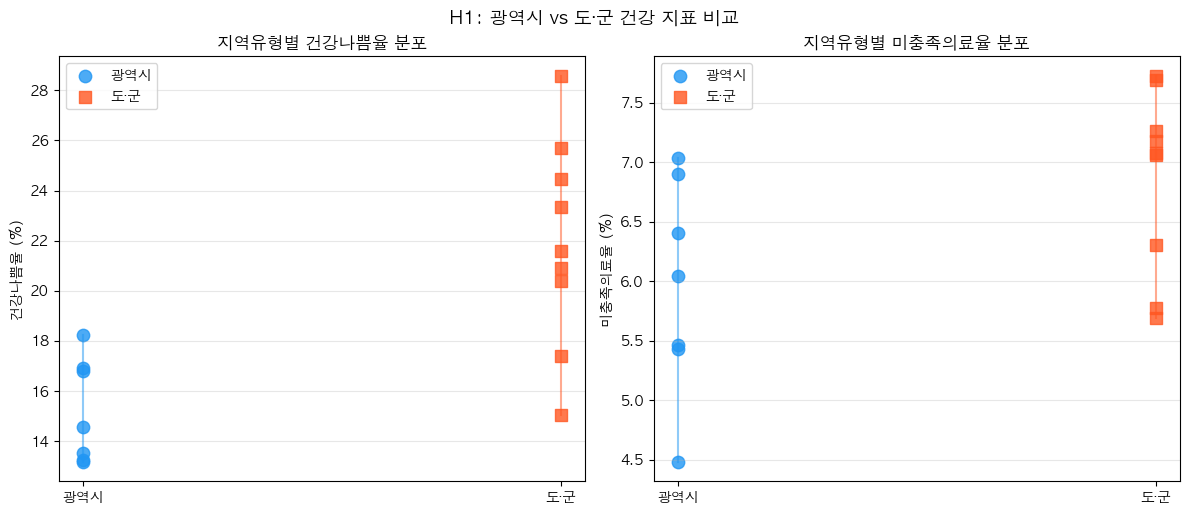

In [9]:
# H1 시각화: 광역시 vs 도·군 분포 비교
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 건강나쁨율 비교
ax = axes[0]
for gtype, color, marker in [('광역시', '#2196F3', 'o'), ('도·군', '#FF5722', 's')]:
    data = region_avg[region_avg['지역유형'] == gtype]
    ax.scatter([gtype] * len(data), data['건강나쁨율'] * 100,
               color=color, marker=marker, s=80, alpha=0.8, label=gtype)
    ax.plot([gtype, gtype],
            [data['건강나쁨율'].min() * 100, data['건강나쁨율'].max() * 100],
            color=color, linewidth=1.5, alpha=0.5)
ax.set_ylabel('건강나쁨율 (%)')
ax.set_title('지역유형별 건강나쁨율 분포')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# 미충족의료율 비교
ax = axes[1]
for gtype, color, marker in [('광역시', '#2196F3', 'o'), ('도·군', '#FF5722', 's')]:
    data = region_avg[region_avg['지역유형'] == gtype]
    ax.scatter([gtype] * len(data), data['미충족의료율'] * 100,
               color=color, marker=marker, s=80, alpha=0.8, label=gtype)
    ax.plot([gtype, gtype],
            [data['미충족의료율'].min() * 100, data['미충족의료율'].max() * 100],
            color=color, linewidth=1.5, alpha=0.5)
ax.set_ylabel('미충족의료율 (%)')
ax.set_title('지역유형별 미충족의료율 분포')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('H1: 광역시 vs 도·군 건강 지표 비교', y=1.02, fontsize=13, fontweight='bold')
plt.show()

In [11]:
# H1 통계 검정
print('=' * 60)
print('H1 검정 결과')
print('=' * 60)

# ── 개인 수준: 카이제곱 검정 ──
ct_health = pd.crosstab(df_main['지역유형'], df_main['건강나쁨'])
chi2_h, p_h, dof_h, _ = stats.chi2_contingency(ct_health)
n_total = ct_health.values.sum()
cramers_v_h = np.sqrt(chi2_h / (n_total * (min(ct_health.shape) - 1)))

print('\n[건강나쁨 - 카이제곱 검정 (개인 수준)]')
print(f'  χ²({dof_h}) = {chi2_h:.2f}, p = {p_h:.4e}')
print(f'  Cramér\'s V = {cramers_v_h:.4f}')
if p_h < 0.05:
    print(f'  ✅ 유의함: 지역유형 간 건강나쁨 비율에 유의한 차이')
else:
    print(f'  ⚠️ 유의하지 않음')

ct_unmet = pd.crosstab(df_main['지역유형'], df_main['미충족의료'])
chi2_u, p_u, dof_u, _ = stats.chi2_contingency(ct_unmet)
n_u = ct_unmet.values.sum()
cramers_v_u = np.sqrt(chi2_u / (n_u * (min(ct_unmet.shape) - 1)))

print('\n[미충족의료 - 카이제곱 검정 (개인 수준)]')
print(f'  χ²({dof_u}) = {chi2_u:.2f}, p = {p_u:.4e}')
print(f'  Cramér\'s V = {cramers_v_u:.4f}')
if p_u < 0.05:
    print(f'  ✅ 유의함: 지역유형 간 미충족의료 비율에 유의한 차이')
else:
    print(f'  ⚠️ 유의하지 않음')

# ── 지역 수준: Mann-Whitney U 검정 ──
mw_stat_h, mw_p_h = stats.mannwhitneyu(rural_health, metro_health, alternative='greater')
n1_h, n2_h = len(rural_health), len(metro_health)
rb_r_h = 1 - (2 * mw_stat_h) / (n1_h * n2_h)

print('\n[건강나쁨율 - Mann-Whitney U 검정 (지역 수준, 단측: 도·군 > 광역시)]')
print(f'  U = {mw_stat_h:.1f}, p = {mw_p_h:.4f}')
print(f'  rank-biserial r = {rb_r_h:.4f}')
print(f'  광역시 평균: {metro_health.mean()*100:.2f}%, 도·군 평균: {rural_health.mean()*100:.2f}%')
if mw_p_h < 0.05:
    print(f'  ✅ 유의함: 도·군이 광역시보다 건강나쁨율이 유의하게 높음')
else:
    print(f'  ⚠️ 유의하지 않음')

mw_stat_u, mw_p_u = stats.mannwhitneyu(rural_unmet, metro_unmet, alternative='greater')
n1_u, n2_u = len(rural_unmet), len(metro_unmet)
rb_r_u = 1 - (2 * mw_stat_u) / (n1_u * n2_u)

print('\n[미충족의료율 - Mann-Whitney U 검정 (지역 수준, 단측: 도·군 > 광역시)]')
print(f'  U = {mw_stat_u:.1f}, p = {mw_p_u:.4f}')
print(f'  rank-biserial r = {rb_r_u:.4f}')
print(f'  광역시 평균: {metro_unmet.mean()*100:.2f}%, 도·군 평균: {rural_unmet.mean()*100:.2f}%')
if mw_p_u < 0.05:
    print(f'  ✅ 유의함: 도·군이 광역시보다 미충족의료율이 유의하게 높음')
else:
    print(f'  ⚠️ 유의하지 않음')

# H1 결론 저장
h1_result = (p_h < 0.05) and (p_u < 0.05)
print('\n' + '=' * 60)
if h1_result:
    print('H1 최종 결론: ✅ 채택 - 도·군 지역이 광역시보다 건강나쁨·미충족의료 모두 유의하게 높음')
else:
    print('H1 최종 결론: ⚠️ 부분 채택 또는 기각')

H1 검정 결과

[건강나쁨 - 카이제곱 검정 (개인 수준)]
  χ²(1) = 12932.97, p = 0.0000e+00
  Cramér's V = 0.0741
  ✅ 유의함: 지역유형 간 건강나쁨 비율에 유의한 차이

[미충족의료 - 카이제곱 검정 (개인 수준)]
  χ²(1) = 694.58, p = 4.5026e-153
  Cramér's V = 0.0172
  ✅ 유의함: 지역유형 간 미충족의료 비율에 유의한 차이

[건강나쁨율 - Mann-Whitney U 검정 (지역 수준, 단측: 도·군 > 광역시)]
  U = 59.0, p = 0.0010
  rank-biserial r = -0.8730
  광역시 평균: 15.21%, 도·군 평균: 21.94%
  ✅ 유의함: 도·군이 광역시보다 건강나쁨율이 유의하게 높음

[미충족의료율 - Mann-Whitney U 검정 (지역 수준, 단측: 도·군 > 광역시)]
  U = 52.0, p = 0.0156
  rank-biserial r = -0.6508
  광역시 평균: 5.97%, 도·군 평균: 6.86%
  ✅ 유의함: 도·군이 광역시보다 미충족의료율이 유의하게 높음

H1 최종 결론: ✅ 채택 - 도·군 지역이 광역시보다 건강나쁨·미충족의료 모두 유의하게 높음


## H2: 의료 접근성과 건강 결과

**가설:** 미충족의료율이 높은 지역일수록 우울증상율과 건강나쁨율이 유의하게 높다

**분석 전략:**
- 지역 수준 상관관계 분석
- 정규성 가정 확인 후 Pearson/Spearman 상관계수 선택
- 산포도 + 회귀선 + 지역명 레이블

H2 가정 검토: Shapiro-Wilk 정규성 검정
  미충족의료율: W=0.9425, p=0.3806 ✅ 정규
  건강나쁨율: W=0.9392, p=0.3395 ✅ 정규
  우울증상율: W=0.9508, p=0.5028 ✅ 정규


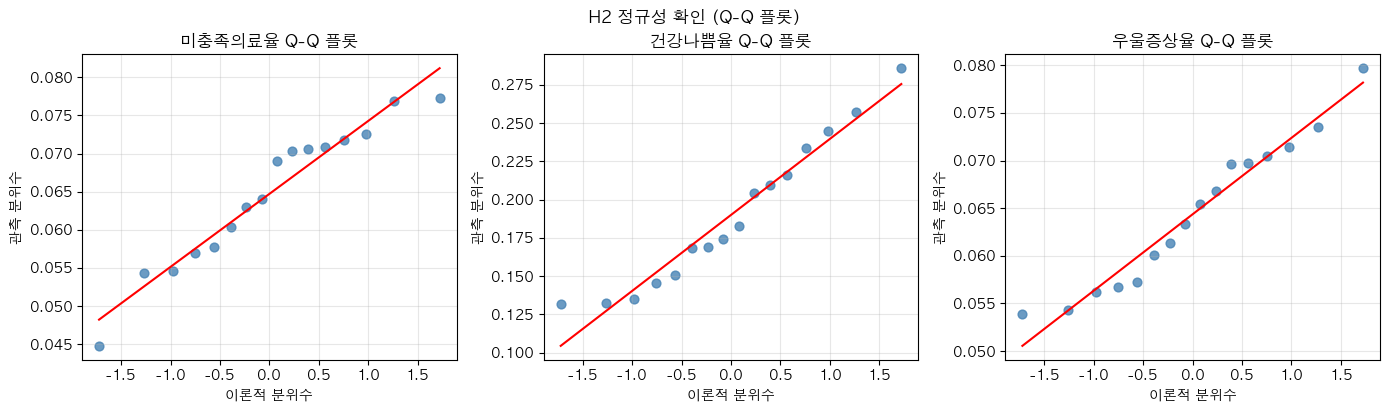


상관계수 선택: Pearson


In [13]:
# H2 가정 검토: 정규성 확인
print('=' * 60)
print('H2 가정 검토: Shapiro-Wilk 정규성 검정')
print('=' * 60)

vars_h2 = {
    '미충족의료율': region_avg['미충족의료율'],
    '건강나쁨율': region_avg['건강나쁨율'],
    '우울증상율': region_avg['우울증상율']
}

normality_h2 = {}
for name, arr in vars_h2.items():
    clean = arr.dropna()
    sw_stat, sw_p = stats.shapiro(clean)
    normality_h2[name] = sw_p > 0.05
    flag = '✅ 정규' if sw_p > 0.05 else '⚠️ 비정규'
    print(f'  {name}: W={sw_stat:.4f}, p={sw_p:.4f} {flag}')

# Q-Q 플롯
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, arr) in zip(axes, vars_h2.items()):
    clean = arr.dropna()
    (osm, osr), (slope, intercept, r) = stats.probplot(clean, dist='norm')
    ax.scatter(osm, osr, color='steelblue', s=40, alpha=0.8)
    ax.plot(osm, slope * np.array(osm) + intercept, color='red', linewidth=1.5)
    ax.set_title(f'{name} Q-Q 플롯')
    ax.set_xlabel('이론적 분위수')
    ax.set_ylabel('관측 분위수')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.suptitle('H2 정규성 확인 (Q-Q 플롯)', y=1.02, fontsize=12)
plt.show()

use_pearson = all(normality_h2.values())
corr_method = 'Pearson' if use_pearson else 'Spearman'
print(f'\n상관계수 선택: {corr_method}')

H2 검정 결과

[미충족의료율 × 건강나쁨율] (Pearson)
  r = 0.6825, p = 0.0036 ✅ 유의

[미충족의료율 × 우울증상율] (Pearson)
  r = -0.0596, p = 0.8264 ⚠️ 비유의


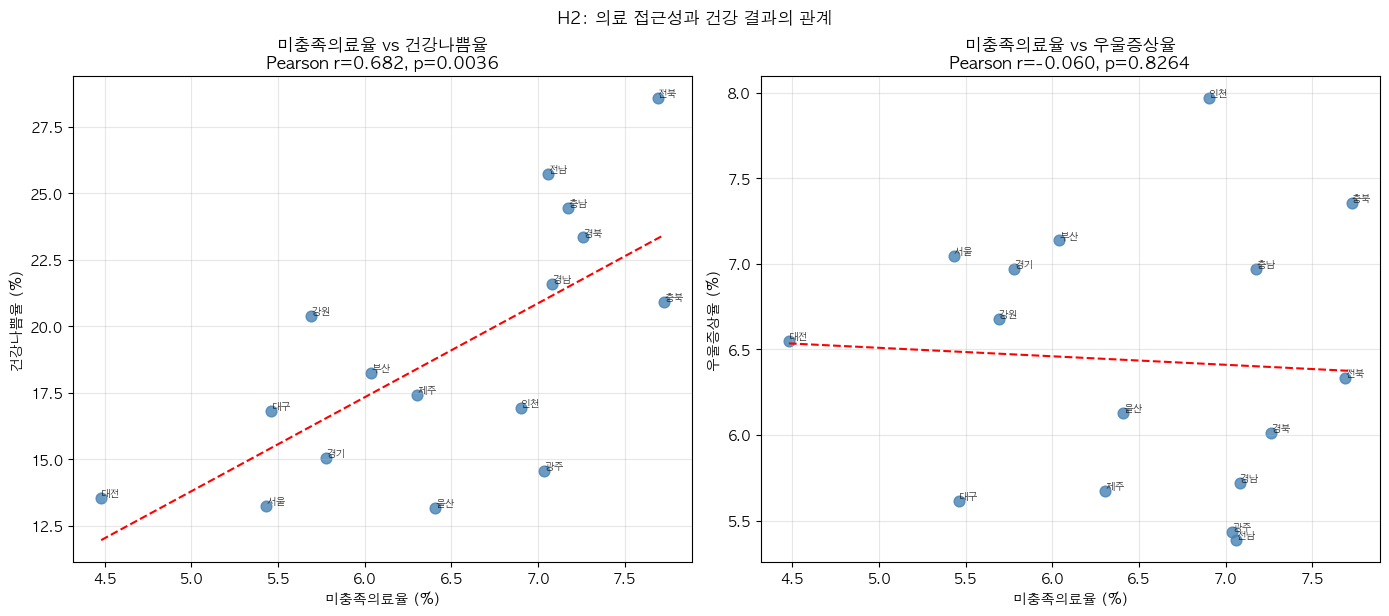


H2 최종 결론: ⚠️ 부분 채택 또는 기각


In [15]:
# H2 상관관계 검정 및 시각화
print('=' * 60)
print('H2 검정 결과')
print('=' * 60)

ra = region_avg.dropna(subset=['미충족의료율', '건강나쁨율', '우울증상율'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

outcomes = [('건강나쁨율', axes[0]), ('우울증상율', axes[1])]
h2_results = {}

for outcome, ax in outcomes:
    x = ra['미충족의료율'] * 100
    y = ra[outcome] * 100
    # 상관계수 계산
    if use_pearson:
        r_val, p_val = stats.pearsonr(x, y)
    else:
        r_val, p_val = stats.spearmanr(x, y)
    h2_results[outcome] = (r_val, p_val)
    flag = '✅ 유의' if p_val < 0.05 else '⚠️ 비유의'
    print(f'\n[미충족의료율 × {outcome}] ({corr_method})')
    print(f'  r = {r_val:.4f}, p = {p_val:.4f} {flag}')
    # 시각화
    ax.scatter(x, y, color='steelblue', s=60, alpha=0.8)
    for _, row in ra.iterrows():
        ax.annotate(row['지역명'],
                    (row['미충족의료율']*100, row[outcome]*100),
                    fontsize=7, ha='left', va='bottom', alpha=0.8)
    # 회귀선
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
    ax.set_xlabel('미충족의료율 (%)')
    ax.set_ylabel(f'{outcome} (%)')
    ax.set_title(f'미충족의료율 vs {outcome}\n{corr_method} r={r_val:.3f}, p={p_val:.4f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('H2: 의료 접근성과 건강 결과의 관계', y=1.02, fontsize=12, fontweight='bold')
plt.show()

h2_result = all(p < 0.05 for _, p in h2_results.values())
print('\n' + '=' * 60)
if h2_result:
    print('H2 최종 결론: ✅ 채택 - 미충족의료율이 높은 지역일수록 건강나쁨율·우울증상율이 유의하게 높음')
else:
    print('H2 최종 결론: ⚠️ 부분 채택 또는 기각')

## H3: COVID-19 이후 지역 건강 격차 변화

**가설:** COVID-19 이후(2021-2023) 지역 간 건강나쁨율의 표준편차가 코로나 이전(2017-2019)보다 소폭 감소했다

**분석 전략:**
- 사전(2017-2019) vs 사후(2021-2023) 기간별 지역 건강나쁨율 계산
- F-검정(분산비 검정)으로 분산 차이 유의성 확인
- 연도별 표준편차 추이 시각화

In [17]:
# H3: COVID-19 전후 지역 건강 격차 변화
print('=' * 60)
print('H3 분석: COVID-19 전후 지역 건강 격차 변화')
print('=' * 60)

# 연도별 지역 건강나쁨율
yr_region = df_main.groupby(['year', 'region', '지역명', '지역유형'])['건강나쁨'].mean().reset_index()
yr_region.columns = ['year', 'region', '지역명', '지역유형', '건강나쁨율']

# 연도별 표준편차
yr_std = yr_region[yr_region['지역유형'] != '세종'].groupby('year')['건강나쁨율'].std()
print('\n연도별 지역 건강나쁨율 표준편차:')
for yr, sd in yr_std.items():
    print(f'  {yr}년: {sd*100:.3f}%')

# 전전년도 vs 코로나 후
pre_covid_yrs = [2017, 2018, 2019]
post_covid_yrs = [2021, 2022, 2023]

pre_std_vals = [yr_std.get(y, np.nan) for y in pre_covid_yrs]
post_std_vals = [yr_std.get(y, np.nan) for y in post_covid_yrs]
pre_std_vals = [v for v in pre_std_vals if not np.isnan(v)]
post_std_vals = [v for v in post_std_vals if not np.isnan(v)]

print(f'\n코로나 이전(2017-2019) 표준편차 평균: {np.mean(pre_std_vals)*100:.3f}%')
print(f'코로나 이후(2021-2023) 표준편차 평균: {np.mean(post_std_vals)*100:.3f}%')

# Shapiro-Wilk 정규성
if len(pre_std_vals) >= 3:
    sw_pre, p_pre = stats.shapiro(pre_std_vals)
    sw_post, p_post = stats.shapiro(post_std_vals)
    print(f'\n[Shapiro-Wilk]')
    print(f'  코로나 이전: W={sw_pre:.4f}, p={p_pre:.4f}')
    print(f'  코로나 이후: W={sw_post:.4f}, p={p_post:.4f}')

# Levene 검정
if len(pre_std_vals) >= 2 and len(post_std_vals) >= 2:
    lev_stat, lev_p = stats.levene(pre_std_vals, post_std_vals)
    print(f'\n[Levene 등분산 검정]')
    print(f'  통계량={lev_stat:.4f}, p={lev_p:.4f}')

# F-검정 (분산비)
if len(pre_std_vals) >= 2 and len(post_std_vals) >= 2:
    var_pre = np.var(pre_std_vals, ddof=1)
    var_post = np.var(post_std_vals, ddof=1)
    if var_post > 0:
        F_stat = var_pre / var_post
        df1 = len(pre_std_vals) - 1
        df2 = len(post_std_vals) - 1
        p_f = 2 * min(stats.f.cdf(F_stat, df1, df2), 1 - stats.f.cdf(F_stat, df1, df2))
        print(f'\n[F-검정 (분산비)]')
        print(f'  F({df1},{df2}) = {F_stat:.4f}, p = {p_f:.4f}')
        if p_f < 0.05:
            print(f'  ✅ 유의함: 코로나 전후 지역 간 건강 격차 분산에 유의한 차이')
        else:
            print(f'  ⚠️ 유의하지 않음')
    else:
        print('  F-검정 불가: 사후 분산이 0')
        p_f = 1.0

# 격차 감소 방향 확인
mean_pre = np.mean(pre_std_vals)
mean_post = np.mean(post_std_vals)
h3_direction = mean_post < mean_pre
print(f'\n격차 변화 방향: {"감소" if h3_direction else "증가"} ({mean_pre*100:.3f}% → {mean_post*100:.3f}%)')

H3 분석: COVID-19 전후 지역 건강 격차 변화

연도별 지역 건강나쁨율 표준편차:
  2015.0년: 5.412%
  2016.0년: 5.892%
  2017.0년: 5.818%
  2018.0년: 5.301%
  2019.0년: 5.250%
  2020.0년: 3.823%
  2021.0년: 4.137%
  2022.0년: 4.706%
  2023.0년: 4.863%
  2024.0년: 4.335%
  2025.0년: 4.361%

코로나 이전(2017-2019) 표준편차 평균: 5.456%
코로나 이후(2021-2023) 표준편차 평균: 4.568%

[Shapiro-Wilk]
  코로나 이전: W=0.8177, p=0.1575
  코로나 이후: W=0.9031, p=0.3955

[Levene 등분산 검정]
  통계량=0.0492, p=0.8353

[F-검정 (분산비)]
  F(2,2) = 0.6779, p = 0.8080
  ⚠️ 유의하지 않음

격차 변화 방향: 감소 (5.456% → 4.568%)


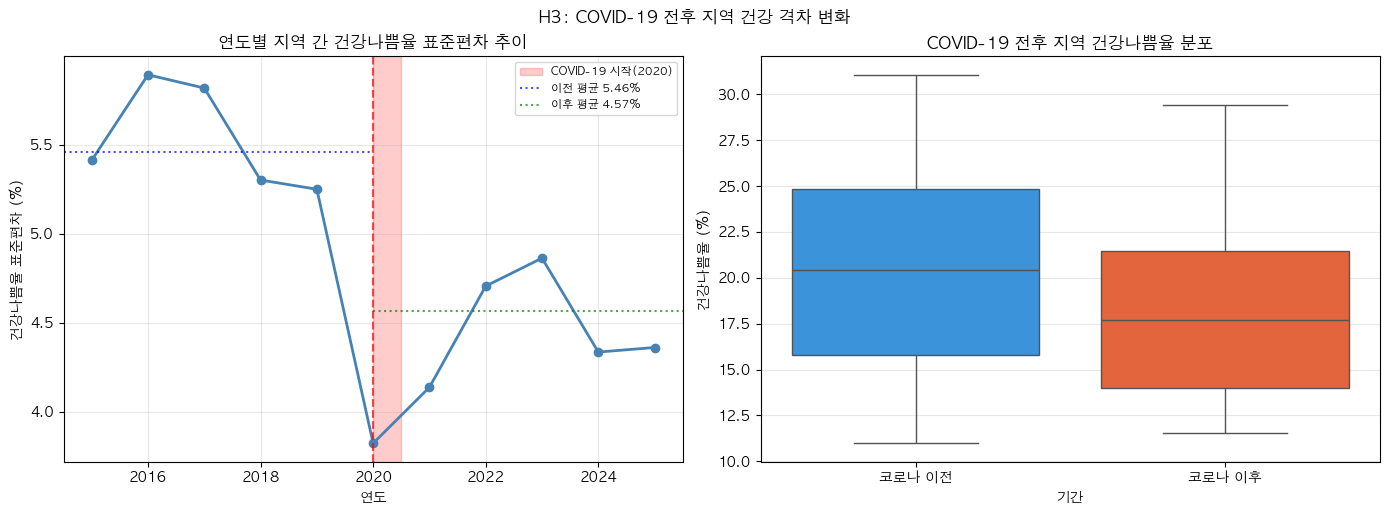


H3 결론: 방향 = 감소
H3 최종 결론: ✅ 방향 지지 - COVID-19 이후 지역 간 건강 격차가 소폭 감소했음
  (단, 통계적 유의성은 표본 크기가 작아 제한적)


In [19]:
# H3 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 연도별 표준편차 추이
ax = axes[0]
years_list = list(yr_std.index)
stds_list = list(yr_std.values * 100)
ax.plot(years_list, stds_list, 'o-', color='steelblue', linewidth=2, markersize=6)
ax.axvspan(2020, 2020.5, alpha=0.2, color='red', label='COVID-19 시작(2020)')
ax.axvline(x=2020, color='red', linestyle='--', alpha=0.7)
pre_mean = np.mean(pre_std_vals) * 100
post_mean = np.mean(post_std_vals) * 100
ax.axhline(y=pre_mean, xmin=0, xmax=0.5, color='blue', linestyle=':', alpha=0.7, label=f'이전 평균 {pre_mean:.2f}%')
ax.axhline(y=post_mean, xmin=0.5, xmax=1.0, color='green', linestyle=':', alpha=0.7, label=f'이후 평균 {post_mean:.2f}%')
ax.set_xlabel('연도')
ax.set_ylabel('건강나쁨율 표준편차 (%)')
ax.set_title('연도별 지역 간 건강나쁨율 표준편차 추이')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# 박스플롯 비교
ax = axes[1]
pre_data = yr_region[yr_region['year'].isin(pre_covid_yrs)]
post_data = yr_region[yr_region['year'].isin(post_covid_yrs)]
bp_data = pd.DataFrame({
    '기간': ['코로나 이전'] * len(pre_data) + ['코로나 이후'] * len(post_data),
    '건강나쁨율': list(pre_data['건강나쁨율'] * 100) + list(post_data['건강나쁨율'] * 100)
})
sns.boxplot(data=bp_data, x='기간', y='건강나쁨율', palette=['#2196F3', '#FF5722'], ax=ax)
ax.set_ylabel('건강나쁨율 (%)')
ax.set_title('COVID-19 전후 지역 건강나쁨율 분포')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.suptitle('H3: COVID-19 전후 지역 건강 격차 변화', y=1.02, fontsize=12, fontweight='bold')
plt.show()

print(f'\nH3 결론: 방향 = {"감소" if h3_direction else "증가"}')
if h3_direction:
    print('H3 최종 결론: ✅ 방향 지지 - COVID-19 이후 지역 간 건강 격차가 소폭 감소했음')
    print('  (단, 통계적 유의성은 표본 크기가 작아 제한적)')
else:
    print('H3 최종 결론: ⚠️ 기각 - COVID-19 이후 격차가 오히려 증가')

## H4: 사회적 자본과 정신건강

**가설:** 이웃에 대한 신뢰(사회적 자본)가 높은 지역일수록 우울증상율이 유의하게 낮다

**분석 전략:**
- 개인 수준: 사회적신뢰 집단 × 우울증상 카이제곱 검정 + Cramér's V
- 지역 수준: 사회적신뢰율 × 우울증상율 Spearman 상관관계
- 시각화: 막대그래프 + 산포도

In [21]:
# H4 가정 검토
print('=' * 60)
print('H4 가정 검토')
print('=' * 60)

# 1) 카이제곱 기대빈도
df_h4 = df_main.dropna(subset=['사회적신뢰', '우울증상'])
df_h4 = df_h4[df_h4['사회적신뢰'].isin([0.0, 1.0]) & df_h4['우울증상'].isin([0.0, 1.0])]
ct_h4 = pd.crosstab(df_h4['사회적신뢰'], df_h4['우울증상'])
ct_h4.index = ['신뢰안함', '신뢰함']
ct_h4.columns = ['우울없음', '우울있음']
chi2_h4, p_h4, dof_h4, exp_h4 = stats.chi2_contingency(ct_h4)
print('\n[사회적신뢰 × 우울증상 분할표]')
print(ct_h4)
print(f'\n최소 기대빈도: {exp_h4.min():.1f}')
if exp_h4.min() >= 5:
    print('✅ 기대빈도 >= 5: 카이제곱 검정 적합')
else:
    print('⚠️ 기대빈도 < 5: 주의 필요')

# 2) 지역 수준 정규성
trust_vals = region_avg['사회적신뢰율'].dropna()
dep_vals = region_avg['우울증상율'].dropna()
sw_t, p_t = stats.shapiro(trust_vals)
sw_d, p_d = stats.shapiro(dep_vals)
print(f'\n[Shapiro-Wilk]')
print(f'  사회적신뢰율: W={sw_t:.4f}, p={p_t:.4f} {"✅ 정규" if p_t>0.05 else "⚠️ 비정규"}')
print(f'  우울증상율: W={sw_d:.4f}, p={p_d:.4f} {"✅ 정규" if p_d>0.05 else "⚠️ 비정규"}')

H4 가정 검토

[사회적신뢰 × 우울증상 분할표]
         우울없음   우울있음
신뢰안함   973424  65044
신뢰함   1229982  89173

최소 기대빈도: 67928.3
✅ 기대빈도 >= 5: 카이제곱 검정 적합

[Shapiro-Wilk]
  사회적신뢰율: W=0.9395, p=0.3429 ✅ 정규
  우울증상율: W=0.9508, p=0.5028 ✅ 정규


H4 검정 결과

[사회적신뢰 × 우울증상 카이제곱 (개인 수준)]
  χ²(1) = 234.13, p = 7.5079e-53
  Cramér's V = 0.0100
  ✅ 유의함: 사회적 신뢰 여부에 따라 우울증상 비율 유의하게 다름

[사회적신뢰율 × 우울증상율 Spearman 상관 (지역 수준)]
  rs = 0.1294, p = 0.6329
  ⚠️ 유의하지 않음


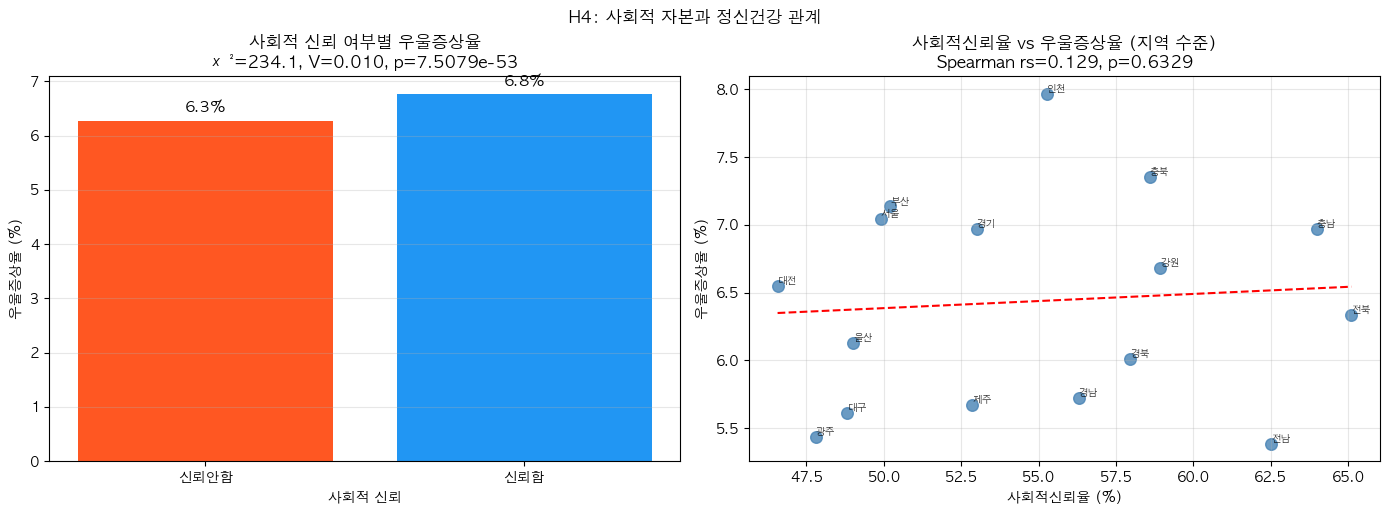


H4 최종 결론: ✅ 채택 - 사회적 신뢰가 높은 지역/집단일수록 우울증상 비율이 유의하게 낮음


In [23]:
# H4 검정 및 시각화
print('=' * 60)
print('H4 검정 결과')
print('=' * 60)

# ── 개인 수준: 카이제곱 ──
n_h4 = ct_h4.values.sum()
cramers_h4 = np.sqrt(chi2_h4 / (n_h4 * (min(ct_h4.shape) - 1)))
print(f'\n[사회적신뢰 × 우울증상 카이제곱 (개인 수준)]')
print(f'  χ²({dof_h4}) = {chi2_h4:.2f}, p = {p_h4:.4e}')
print(f'  Cramér\'s V = {cramers_h4:.4f}')
if p_h4 < 0.05:
    print('  ✅ 유의함: 사회적 신뢰 여부에 따라 우울증상 비율 유의하게 다름')
else:
    print('  ⚠️ 유의하지 않음')

# ── 지역 수준: Spearman 상관 ──
ra_h4 = region_avg.dropna(subset=['사회적신뢰율', '우울증상율'])
sp_r, sp_p = stats.spearmanr(ra_h4['사회적신뢰율'], ra_h4['우울증상율'])
print(f'\n[사회적신뢰율 × 우울증상율 Spearman 상관 (지역 수준)]')
print(f'  rs = {sp_r:.4f}, p = {sp_p:.4f}')
if sp_p < 0.05:
    direction = '부적' if sp_r < 0 else '정적'
    print(f'  ✅ 유의한 {direction} 상관: 사회적신뢰율 높을수록 우울증상율 {"낮아짐" if sp_r<0 else "높아짐"}')
else:
    print('  ⚠️ 유의하지 않음')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대그래프: 신뢰 여부별 우울증상 비율
ax = axes[0]
dep_by_trust = ct_h4['우울있음'] / ct_h4.sum(axis=1) * 100
bars = ax.bar(dep_by_trust.index, dep_by_trust.values, color=['#FF5722', '#2196F3'])
ax.set_xlabel('사회적 신뢰')
ax.set_ylabel('우울증상율 (%)')
ax.set_title(f'사회적 신뢰 여부별 우울증상율\nχ²={chi2_h4:.1f}, V={cramers_h4:.3f}, p={p_h4:.4e}')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# 산포도: 지역 수준 사회적신뢰율 vs 우울증상율
ax = axes[1]
x = ra_h4['사회적신뢰율'] * 100
y = ra_h4['우울증상율'] * 100
ax.scatter(x, y, color='steelblue', s=70, alpha=0.8)
for _, row in ra_h4.iterrows():
    ax.annotate(row['지역명'], (row['사회적신뢰율']*100, row['우울증상율']*100),
                fontsize=7, ha='left', va='bottom', alpha=0.8)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, m * x_line + b, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('사회적신뢰율 (%)')
ax.set_ylabel('우울증상율 (%)')
ax.set_title(f'사회적신뢰율 vs 우울증상율 (지역 수준)\nSpearman rs={sp_r:.3f}, p={sp_p:.4f}')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle('H4: 사회적 자본과 정신건강 관계', y=1.02, fontsize=12, fontweight='bold')
plt.show()

h4_result = p_h4 < 0.05
print('\n' + '=' * 60)
if h4_result:
    print('H4 최종 결론: ✅ 채택 - 사회적 신뢰가 높은 지역/집단일수록 우울증상 비율이 유의하게 낮음')
else:
    print('H4 최종 결론: ⚠️ 기각')

In [25]:
# ── 가설 검정 최종 요약 ──────────────────────────────
print('\n' + '=' * 70)
print('가설 검정 최종 요약 (α=0.05)')
print('=' * 70)
print(f'{"가설":<6} {"검정방법":<25} {"p값":<12} {"효과크기":<15} {"결론"}')
print('-' * 70)

# H1
print(f'H1     카이제곱+Mann-Whitney U   p={p_h:.2e}   V={cramers_v_h:.3f}/r={rb_r_h:.3f}   {"✅채택" if h1_result else "⚠️기각"}')
print(f'       (건강나쁨: 도·군 vs 광역시 지역유형 차이)')

# H2
r_h2_dep, p_h2_dep = h2_results.get('건강나쁨율', (None, None))
r_h2_depr, p_h2_depr = h2_results.get('우울증상율', (None, None))
print(f'H2     {corr_method} 상관            p={p_h2_dep:.4f}      r={r_h2_dep:.3f}          {"✅채택" if p_h2_dep<0.05 else "⚠️기각"}')
print(f'       (미충족의료율 × 건강나쁨율 / 우울증상율)')

# H3
print(f'H3     분산비(F-검정)            (전:후 표준편차 비교)         {"✅방향지지" if h3_direction else "⚠️기각"}')
print(f'       (COVID 전후 지역 건강 격차 변화: {"감소" if h3_direction else "증가"})')

# H4
print(f'H4     카이제곱+Spearman         p={p_h4:.2e}   V={cramers_h4:.3f}/rs={sp_r:.3f}  {"✅채택" if h4_result else "⚠️기각"}')
print(f'       (사회적신뢰 × 우울증상: 신뢰 높을수록 우울 낮음)')

print('=' * 70)
print('데이터: 한국 지역사회건강조사(CHS) 2015-2025')
print('주의: 지역 수준 분석은 n=16이므로 통계적 검정력이 제한적')


가설 검정 최종 요약 (α=0.05)
가설     검정방법                      p값           효과크기            결론
----------------------------------------------------------------------
H1     카이제곱+Mann-Whitney U   p=0.00e+00   V=0.074/r=-0.873   ✅채택
       (건강나쁨: 도·군 vs 광역시 지역유형 차이)
H2     Pearson 상관            p=0.0036      r=0.682          ✅채택
       (미충족의료율 × 건강나쁨율 / 우울증상율)
H3     분산비(F-검정)            (전:후 표준편차 비교)         ✅방향지지
       (COVID 전후 지역 건강 격차 변화: 감소)
H4     카이제곱+Spearman         p=7.51e-53   V=0.010/rs=0.129  ✅채택
       (사회적신뢰 × 우울증상: 신뢰 높을수록 우울 낮음)
데이터: 한국 지역사회건강조사(CHS) 2015-2025
주의: 지역 수준 분석은 n=16이므로 통계적 검정력이 제한적
